In [1]:
# jax ecosystem
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_debug_nans", False)

device = jax.local_devices()[0]
print(device.device_kind)

stats = device.memory_stats()
free = stats["bytes_limit"] - stats["bytes_in_use"]
print(f"Total VRAM : {stats['bytes_limit'] / 1024**3:.2f} GB")
print(f"In use     : {stats['bytes_in_use'] / 1024**3:.2f} GB")
print(f"Free       : {free / 1024**3:.2f} GB")

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
# import dorito
import amigo
import dLux
import zodiax

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os
import sys

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
# plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

if jax.config.read("jax_enable_x64"):
    print("64bit enabled")
else:
    print("32bit enabled")

import equinox
import lineax

print("jax version:", jax.__version__)
print("equinox version:", equinox.__version__)
print("lineax version", lineax.__version__)
print("zodiax version:", zodiax.__version__)
print("dLux version:", dLux.__version__)
print("amigo version:", amigo.__version__)
# print("dorito version:", dorito.__version__)

NVIDIA H200
Total VRAM : 104.79 GB
In use     : 0.00 GB
Free       : 104.79 GB
64bit enabled
jax version: 0.8.3
equinox version: 0.13.7
lineax version 0.1.0
zodiax version: 0.4.1
dLux version: 0.14.3
amigo version: 0.0.10


# Loading in data

In [2]:
# Setting data path
from socket import gethostname

print(f"host name: {gethostname()}")

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    # output_path = "/Users/mc/outputs/GTO1200"

elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    cache_dir = "/home/dgxuser/max/data/amigo_cache"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.10"
    # output_path = "/home/dgxuser/max/outputs/GTO1200"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    # output_path = "/fred/oz440/max/outputs/GTO1200"


# dealing with saving figures when running in script
def check_script():
    if "__file__" in globals():
        print("Running as a script")
        return True
    else:
        print("Running in a notebook or interactive shell")
        return False


# Quick toggle flags
plot_flag = True
# plot_flag = check_script()
save_flag = check_script()

if save_flag:
    
    job_index = int(sys.argv[1])
    
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    task_id = os.environ.get("SLURM_ARRAY_TASK_ID")
    if job_id is not None and task_id is not None:
        job_id = f"{job_id}_{task_id}"
    elif job_id is None:
        from datetime import datetime
        form = "%y-%m-%d_%H-%M-%S_%f"
        now = datetime.now()
        job_id = now.strftime(form)
    print(f"Job ID: {job_id}")
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    import shutil

    shutil.copy(__file__, save_path + "/script.py")

    log_path = os.path.join(save_path, "output.txt")

    class Tee:
        def __init__(self, filename):
            self.file = open(filename, "w")
            self.stdout = sys.stdout

        def write(self, message):
            self.stdout.write(message)
            self.file.write(message)

        def flush(self):
            self.stdout.flush()
            self.file.flush()

    sys.stdout = Tee(log_path)
    sys.stderr = sys.stdout  # capture errors too

else:
    save_path = None

print(f"Save path: {save_path}")
print(f"amigo_files_path: {amigo_files_path}")

host name: max-imagev2-0-47
Running in a notebook or interactive shell
Save path: None
amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.10


In [3]:
# Add extra bad pixels
badpix = np.load(f"{cache_dir}/full_badpix.npy")
badpix = np.array(badpix, dtype=int)

def add_badpix(file):
    file["BADPIX"].data = badpix
    if file[0].header["EXP_TYPE"] == "NIS_DARK":
        file["BADPIX"].data[25, 74] = 1
    return file


# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

## Loading in data and exposures

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files
from amigo.model_fits import PointFit, SplineVisFit

# Collated validator subset
program_path = os.path.join(data_dir, "1843/calslope/")
# files = get_files(program_path, "nis_calslope", FILTER="F480M")
files = get_files(program_path, "nis_calslope")

# Adding bad pixels and summarising metadata
files = [add_badpix(file) for file in files]
summarise_files(files)

# Construct the exposures
# exposures = [PointFit(file) for file in files]
exposures = [SplineVisFit(file) for file in files]

# _ = [f.close() for f in files]

  program     target filter dither     g/i        date              PI    CAL
0    1843  HD-206893  F480M    1/1  11/720  26-10-2022  Kammerer, Jens  False
1    1843  HD-206893  F380M    1/1  4/7046  26-10-2022  Kammerer, Jens  False
2    1843  HD-206893  F430M    1/1  8/2177  26-10-2022  Kammerer, Jens  False
3    1843  HD-205827  F480M    1/1  10/641  26-10-2022  Kammerer, Jens   True
4    1843  HD-205827  F380M    1/1  3/7800  26-10-2022  Kammerer, Jens   True
5    1843  HD-205827  F430M    1/1  7/1885  26-10-2022  Kammerer, Jens   True


# Building model

In [5]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel
from amigo.vis_models import LogVisModel

load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(),
    # optics=AMIOptics(static=False),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    read=ReadModel(),
    vis_model=LogVisModel(load_dict(amigo_files_path + "/vis_basis.npy"), n_basis=420),
    state=load_dict(amigo_files_path + "/calibration.npy"),
    # state=load_dict(amigo_files_path + "/best_state.npy"),
)

Populate from state.

In [6]:
# state = load_dict(amigo_files_path + "/calibration.npy")
# best_state = load_dict(amigo_files_path + "/best_state.npy")
# # state = load_dict(amigo_files_path + "/calibration.npy")
# print(best_state.keys())

# # if "jitter" in state.keys():
#     # state["sigma"] = state["jitter"]
# for key, value in state.items():
# # for key, value in best_state.items():
#     if key not in ["FF", "dark_current", "defocus", "distortion", "non_linearity", "primary_beam", "sigma", "nn_weights"]:
#         continue
#     # if key in ["FF"]:
#         # continue
#     model = model.set(key, value)

## Checking initial fits
Just looking at one per filter. Starting with the calibrator exposures.

File 01843_002_01_05_1
Star HD-205827
Filter F380M
nints 7800
ngroups 3



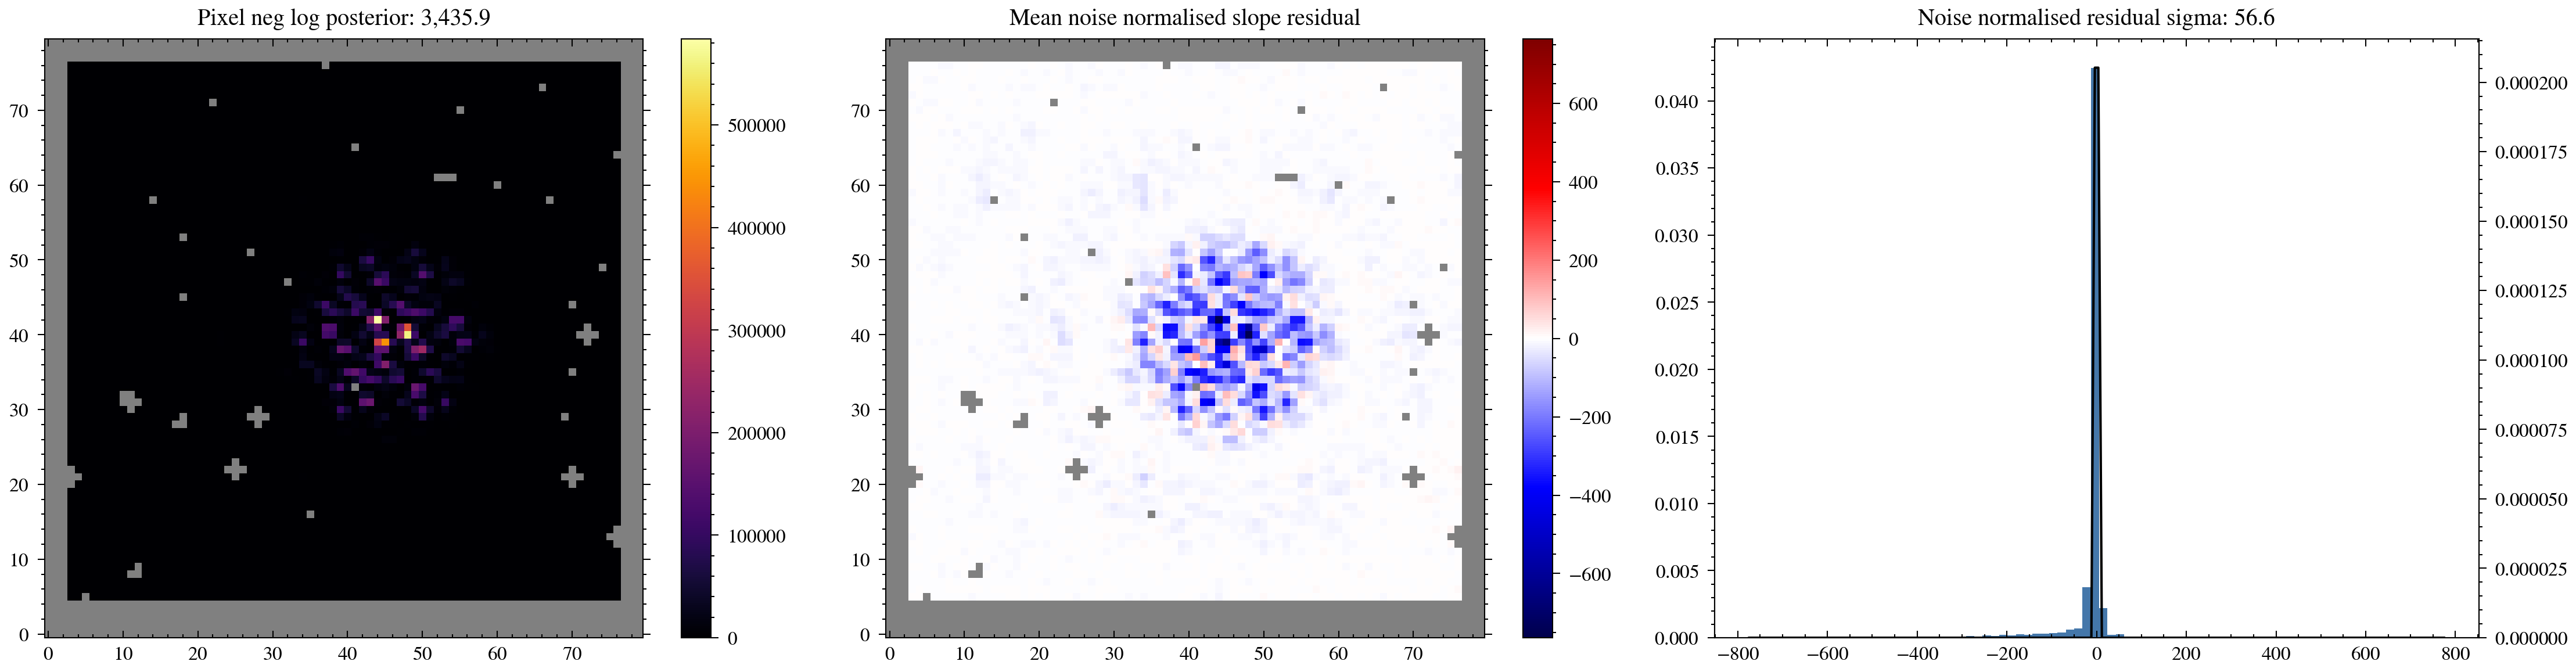

File 01843_002_01_06_1
Star HD-205827
Filter F430M
nints 1885
ngroups 7



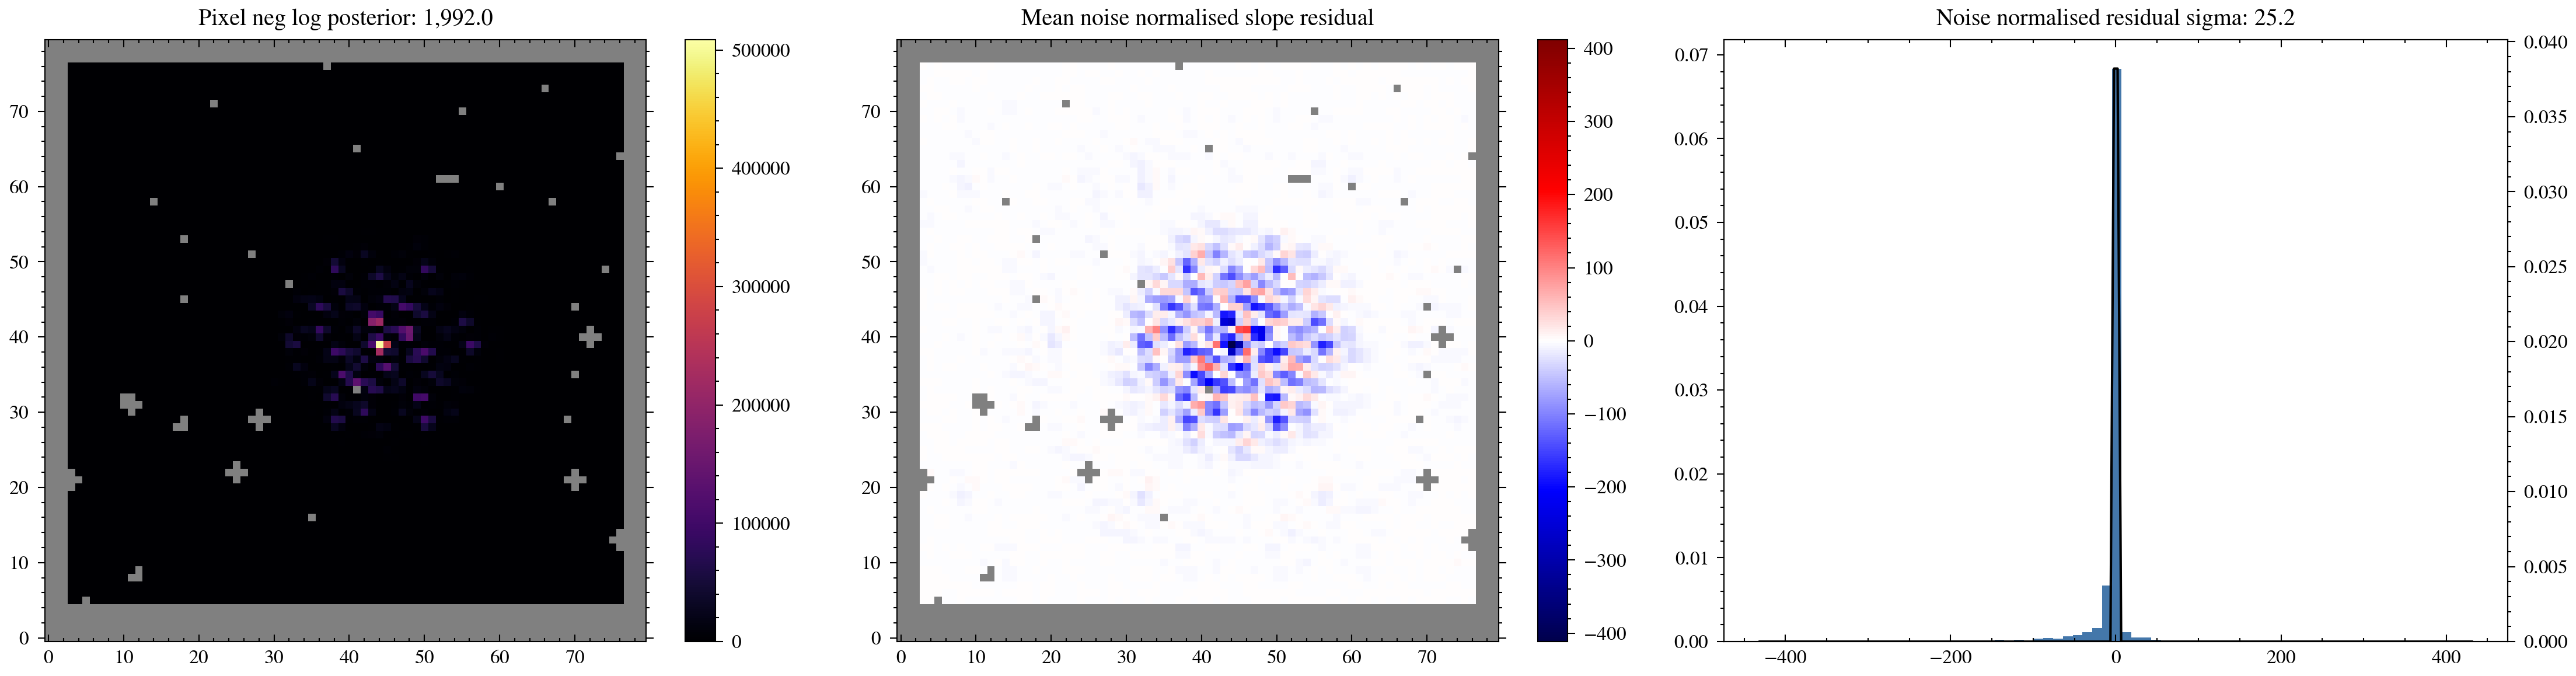

File 01843_001_01_05_1
Star HD-206893
Filter F480M
nints 720
ngroups 11



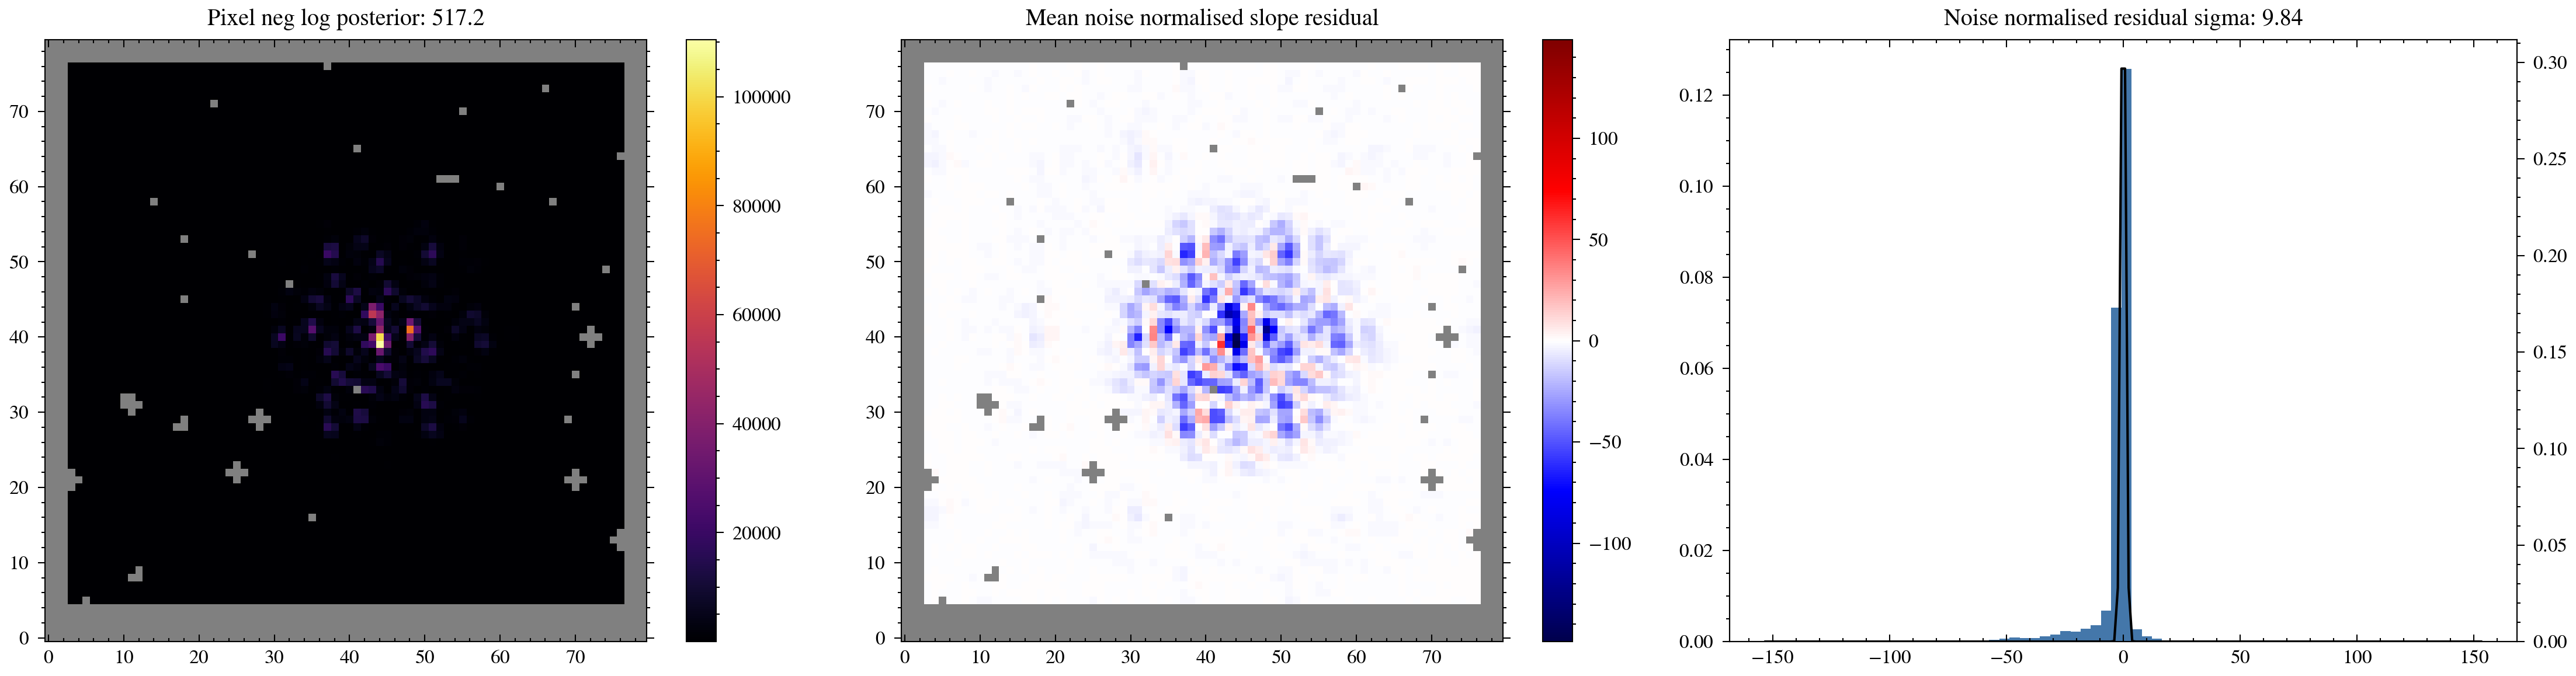

File 01843_001_01_06_1
Star HD-206893
Filter F380M
nints 7046
ngroups 4



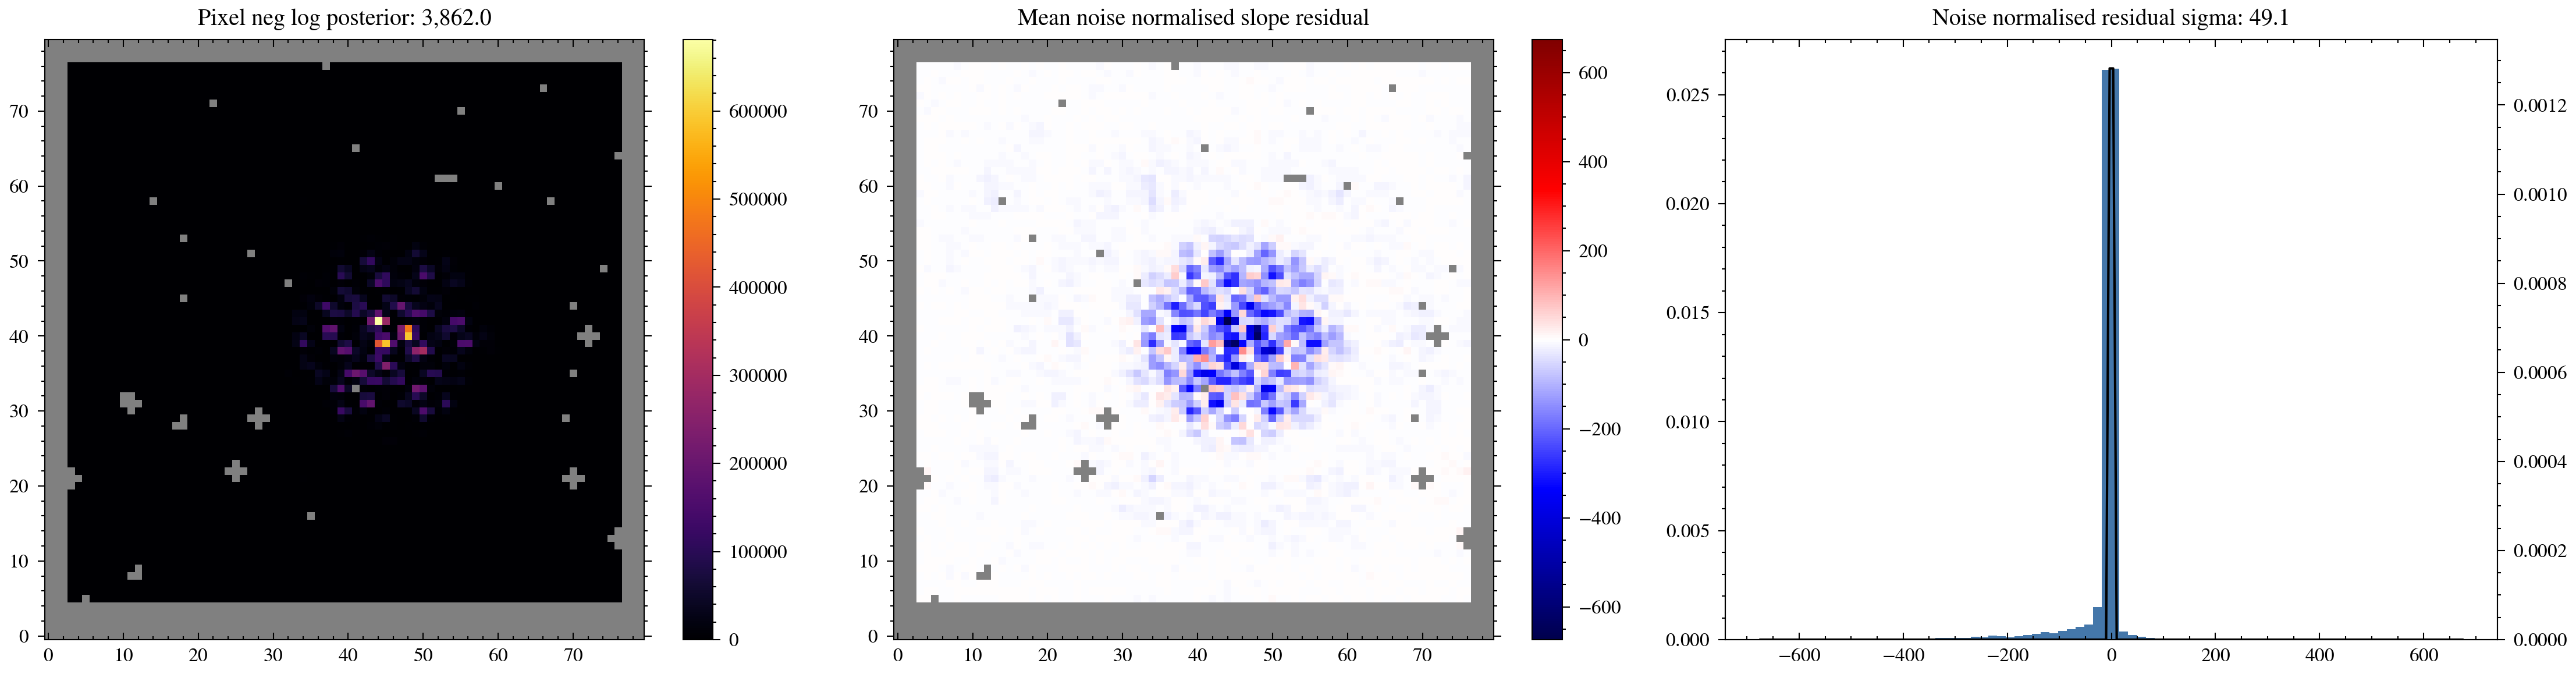

File 01843_001_01_07_1
Star HD-206893
Filter F430M
nints 2177
ngroups 8



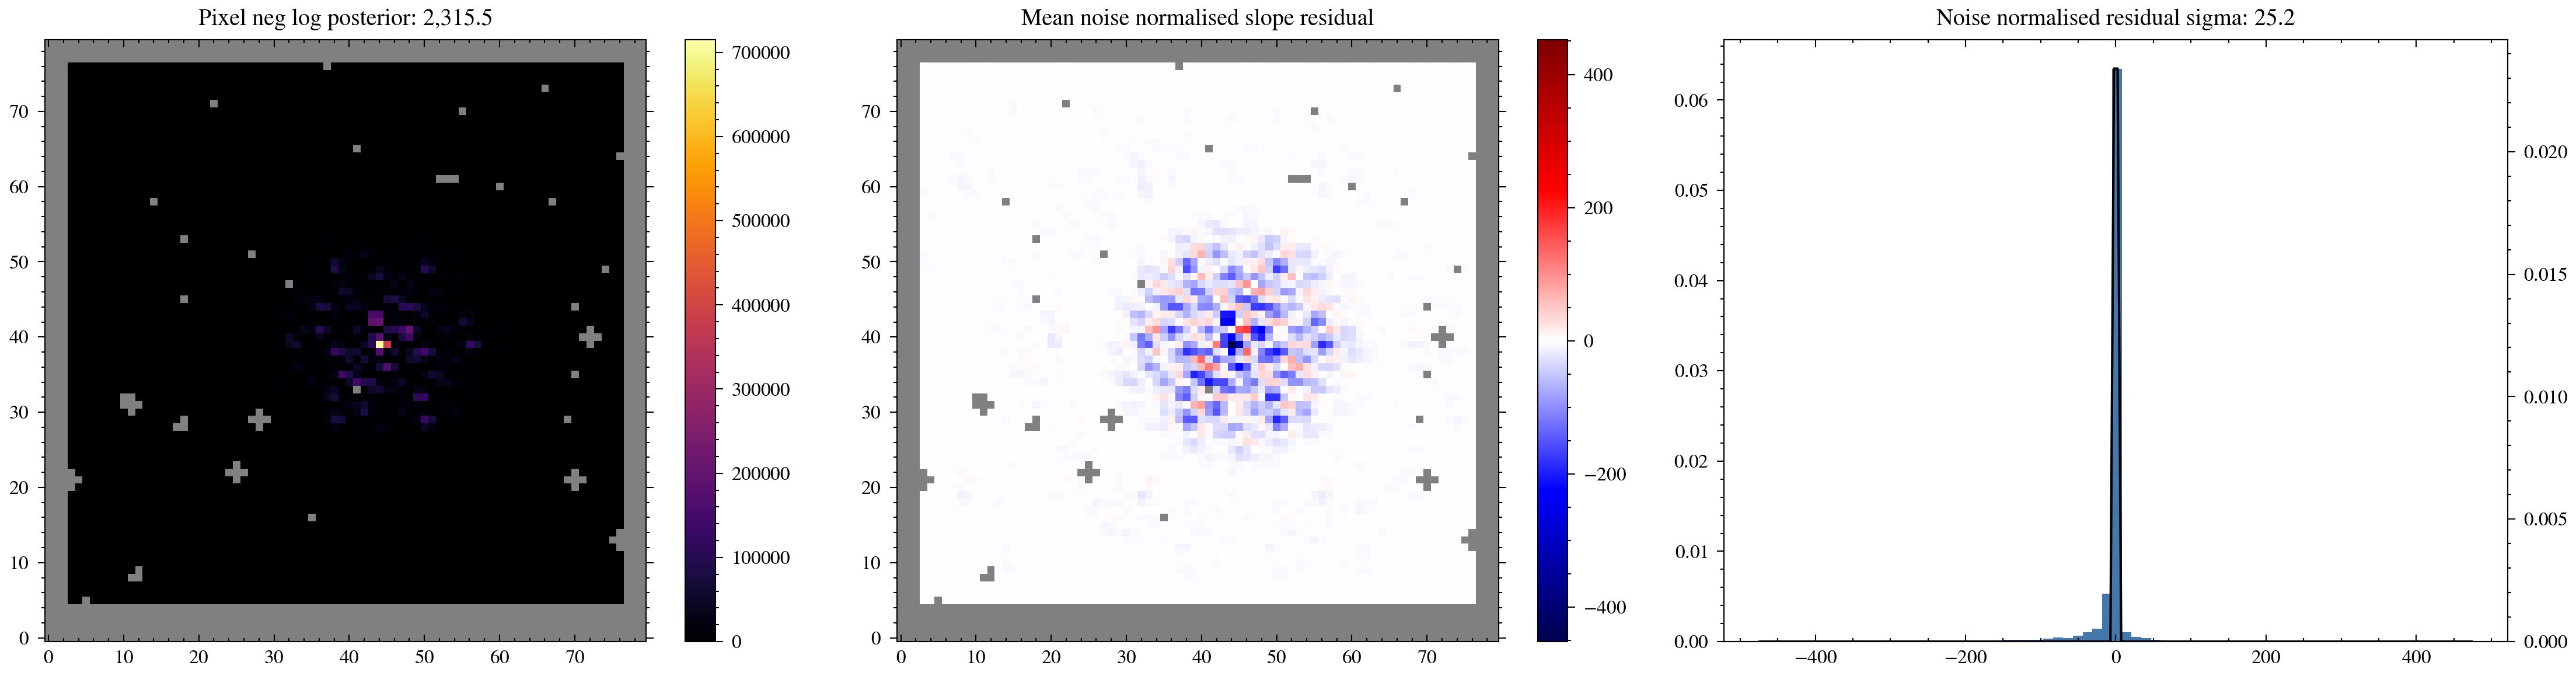

File 01843_002_01_04_1
Star HD-205827
Filter F480M
nints 641
ngroups 10



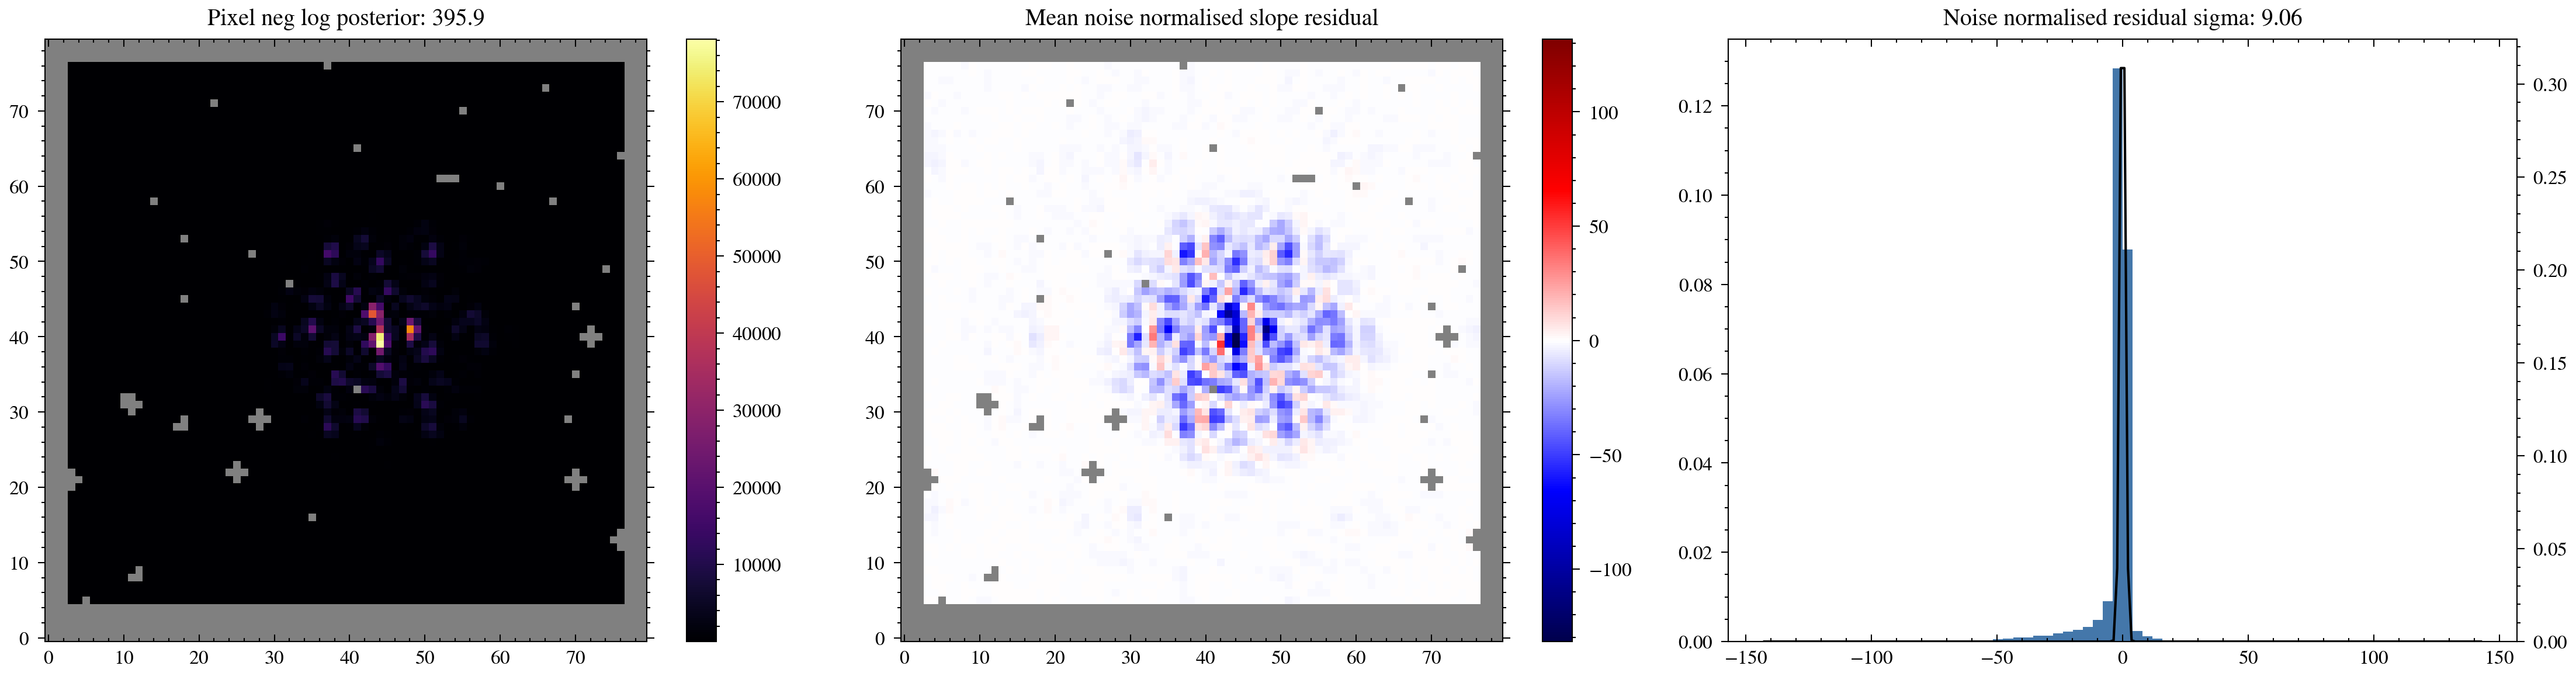

In [7]:
from amigo.plotting import summarise_fit

if plot_flag:
    if save_flag:
        this_save_path = os.path.join(save_path, "init")
        os.mkdir(this_save_path)
    else:
        this_save_path = None
    for exp in exposures:
        exp.print_summary()
        summarise_fit(model, exp, save_path=this_save_path)

# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [8]:
def norm_fn(model_params, args):
    """
    Normalisation function.
    """

    # spectra clipping
    if hasattr(model_params, "spectra"):
        spectra = model_params.spectra
        clip_fn = lambda x: np.clip(x, a_min=-0.8, a_max=0.8)
        spectra = jax.tree.map(clip_fn, spectra)
        model_params = model_params.set("spectra", spectra)

    return model_params, args


Instantiating trainer class and updating fishers.

In [9]:
from amigo.calibration import Trainer
from amigo.fitting import sgd, adam

recalculate_flag = False
epochs = 250

optimisers = {
    "fluxes": sgd(1e-2, 0),
    "positions": sgd(1e-2, 2),
    "aberrations": sgd(1e-3, 5),
    "spectra": sgd(1e-3, 10),
    "amplitudes": sgd(1e-3, 20),
    "phases": sgd(1e-3, 20),
    # "amplitudes": sgd(1e-9, 20),
    # "phases": sgd(1e-9, 20),
}

# Trainer class
trainer = Trainer(
    norm_fn=norm_fn,
    cache=cache_dir,
)

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

trainer = trainer.update_fishers(
    linear_model,
    exposures,
    parameters=list(optimisers.keys()),
    recalculate=recalculate_flag,
)

# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x
model = jtu.map(fn, model)

# Train the model
result = trainer.train(
    model=model,
    optimisers=optimisers,
    epochs=epochs,
    batches=exposures, 
)

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 2,088.36
Estimated run time: 0:05:51
Full Time: 0:07:26
Final Loss: 10.08


Training.

Plotting the results of that fit!

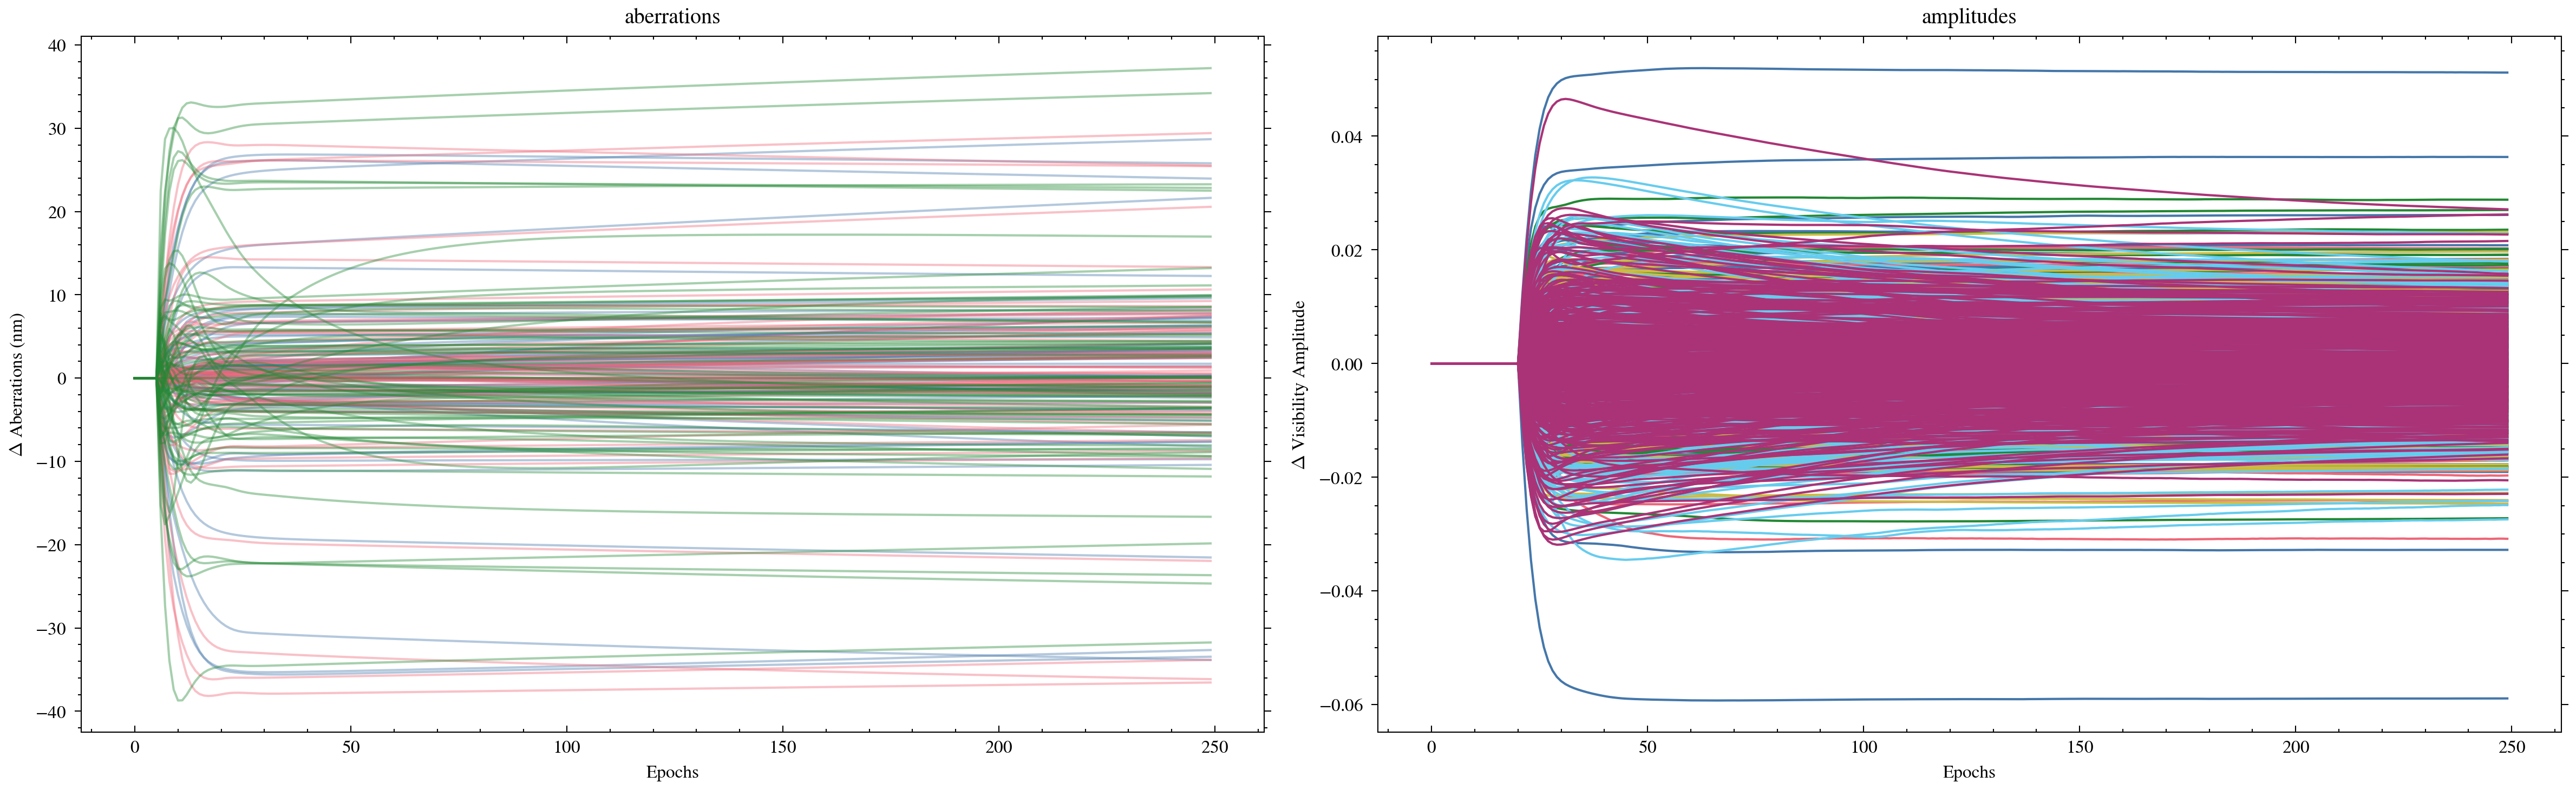

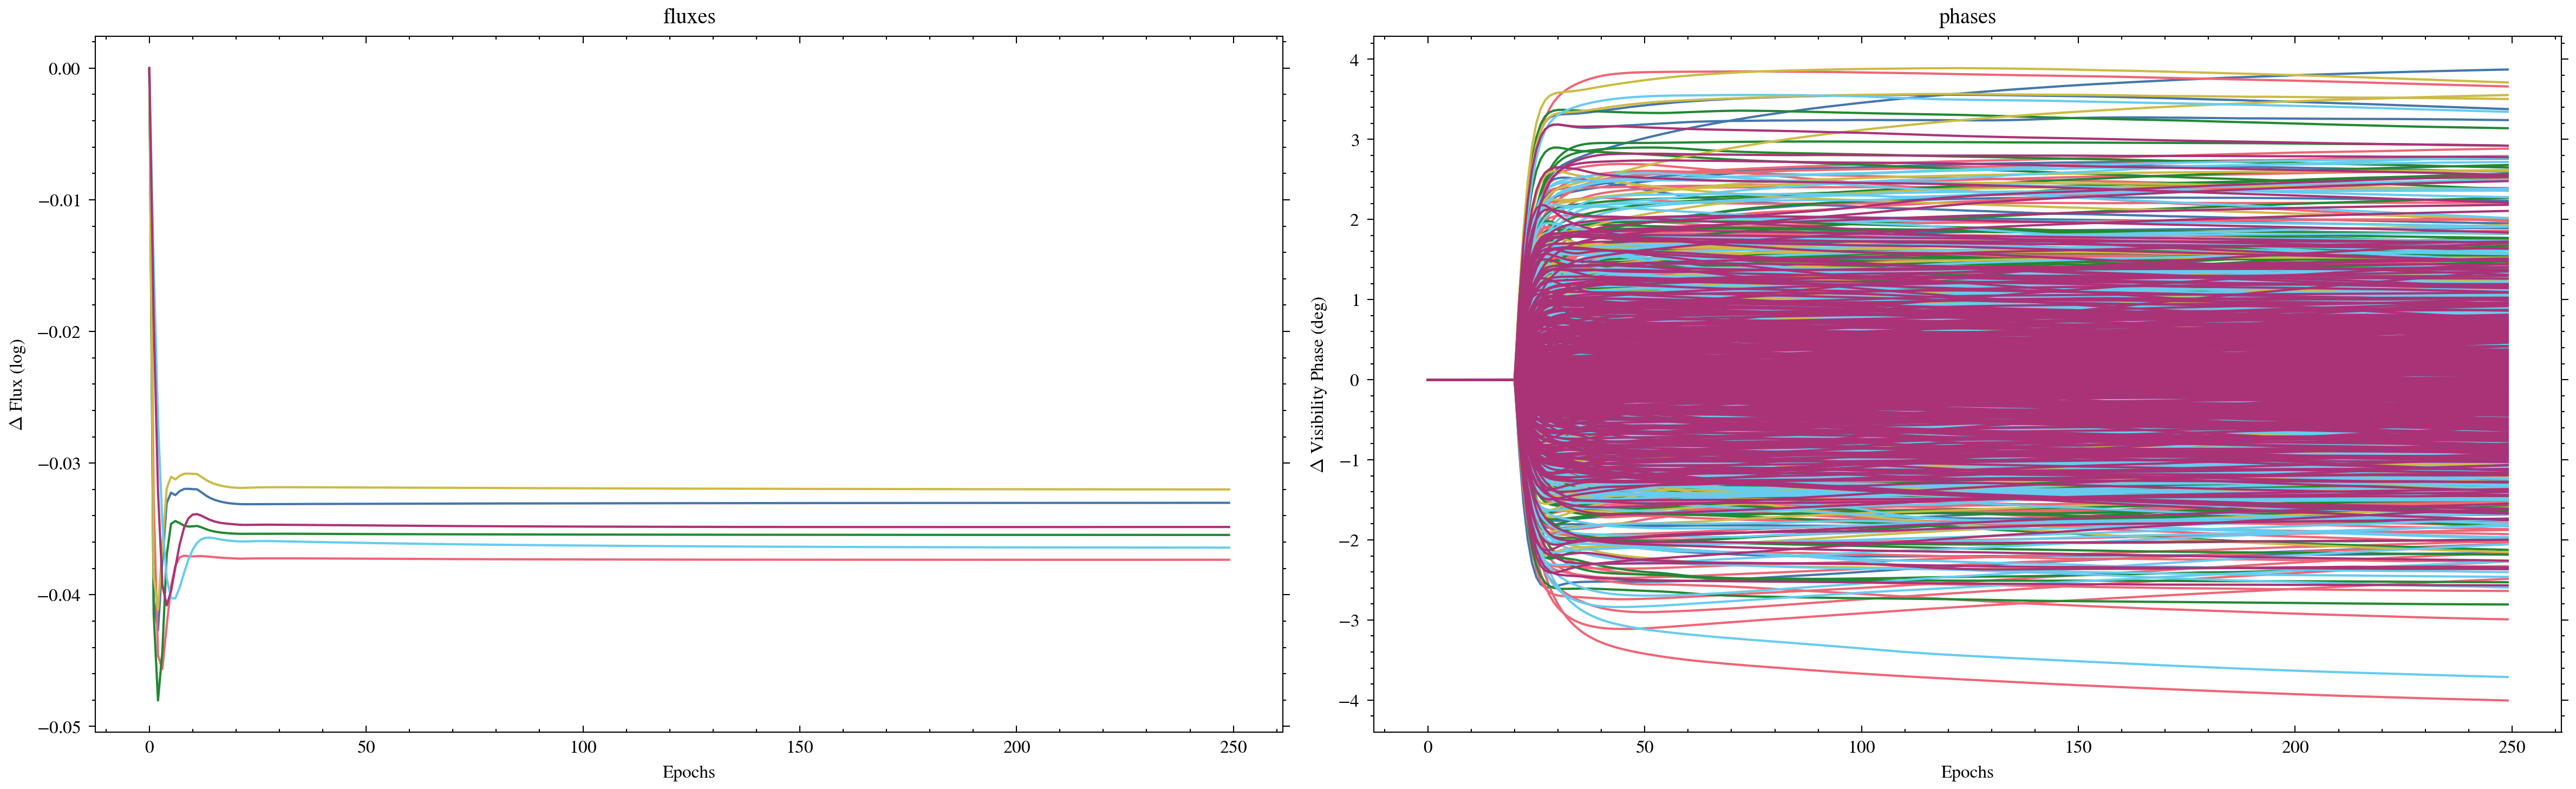

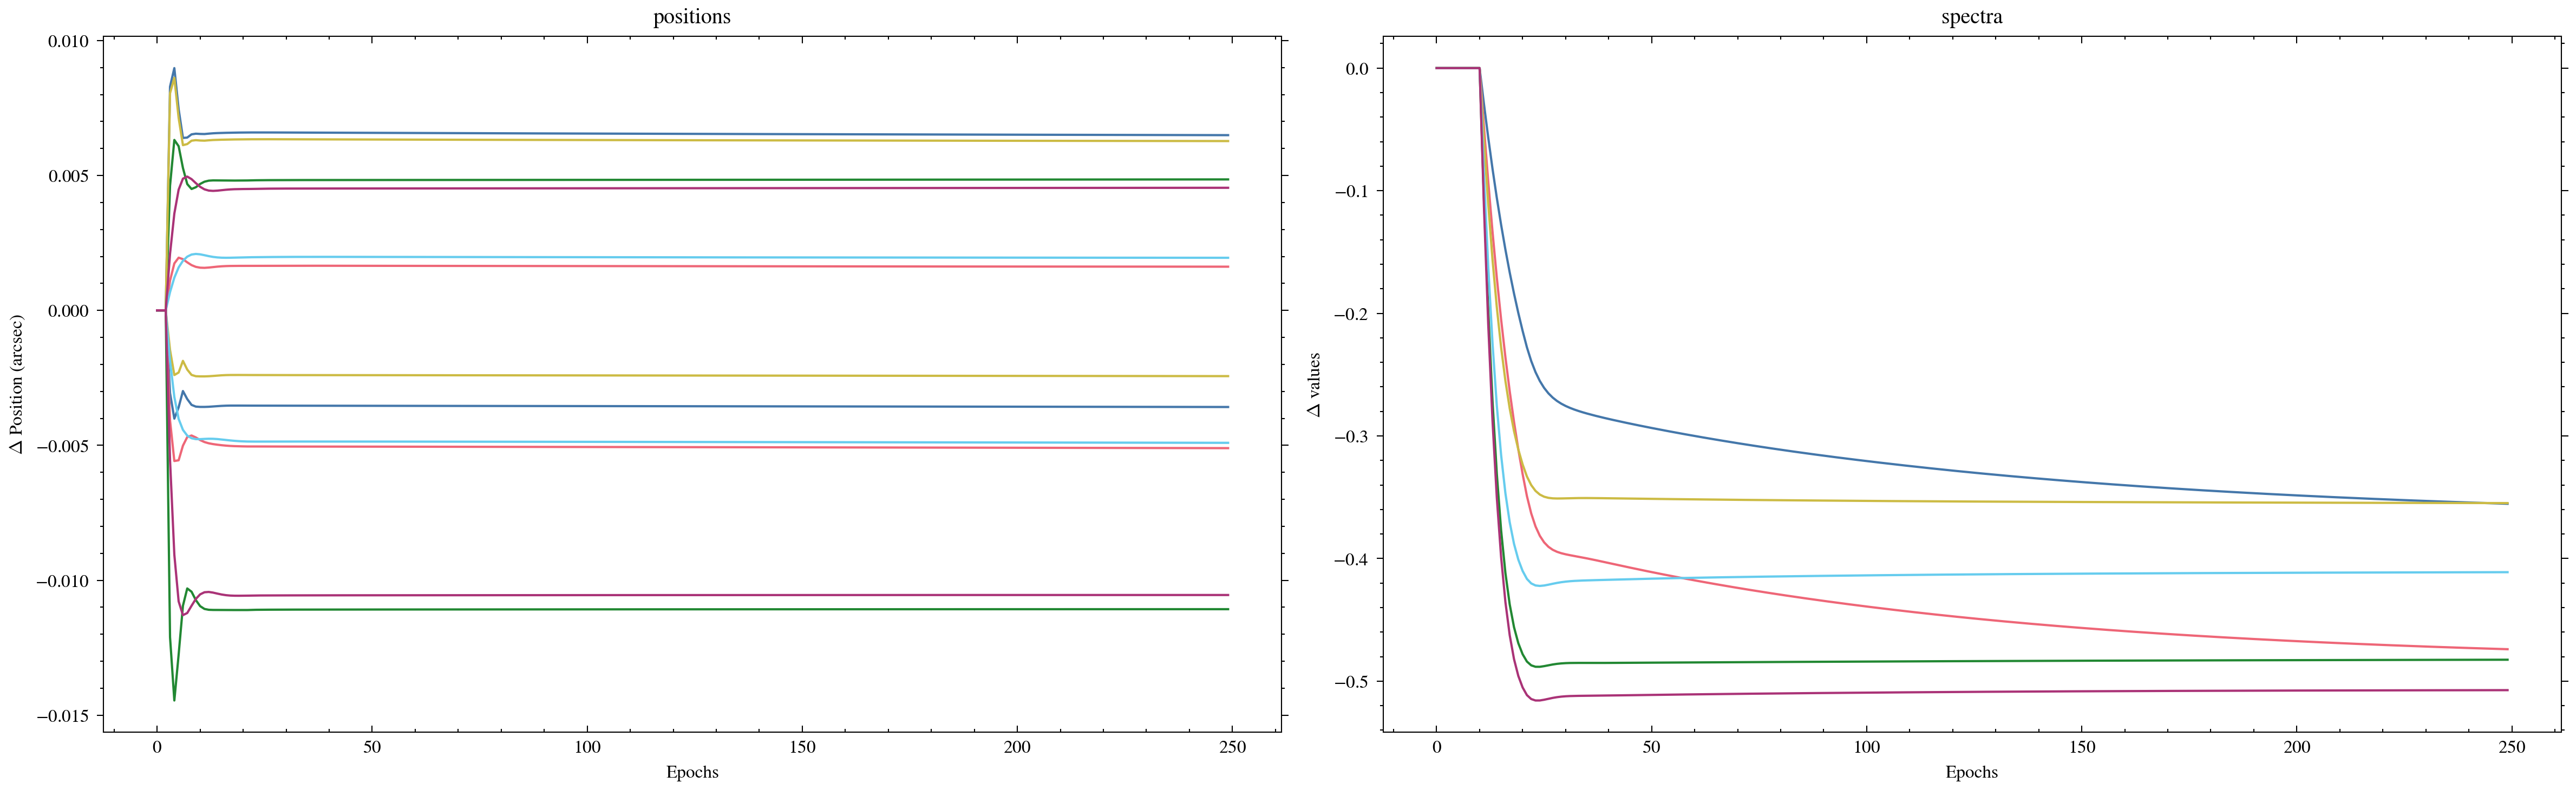

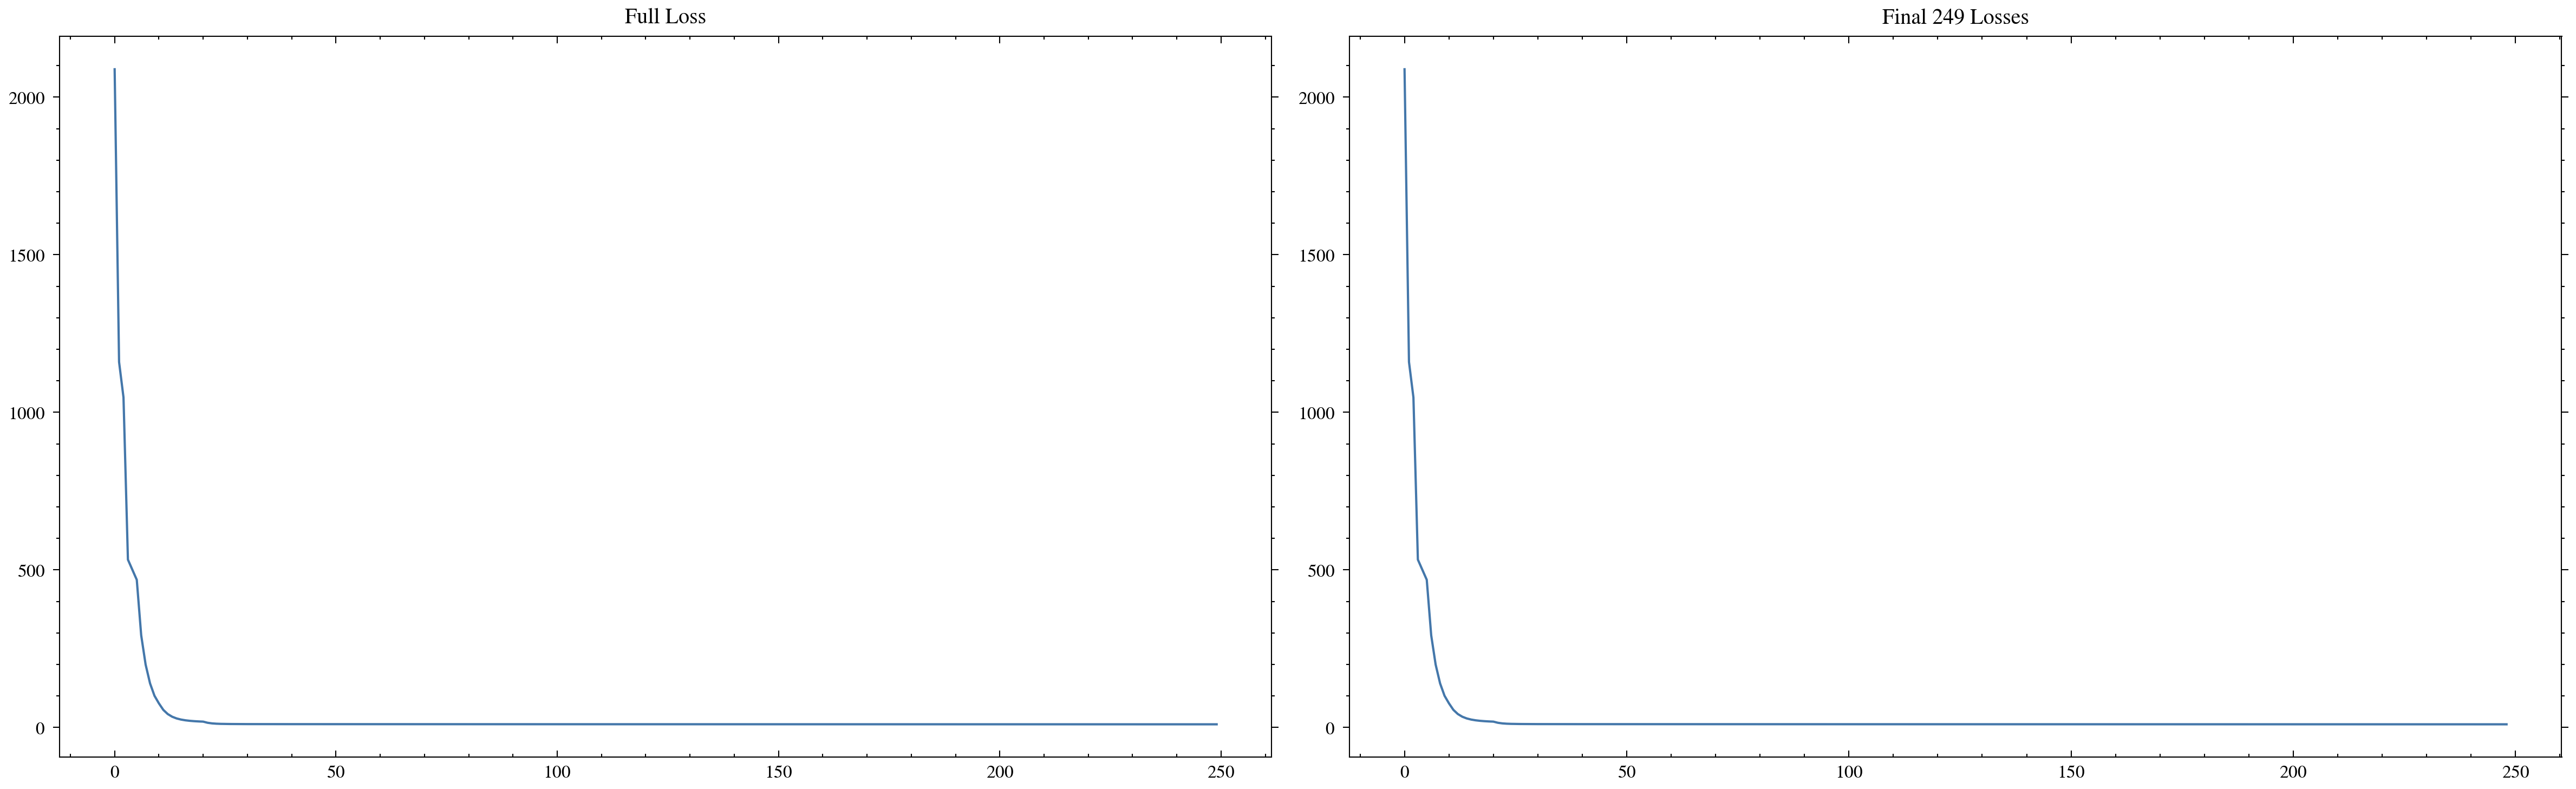

File 01843_002_01_05_1
Star HD-205827
Filter F380M
nints 7800
ngroups 3



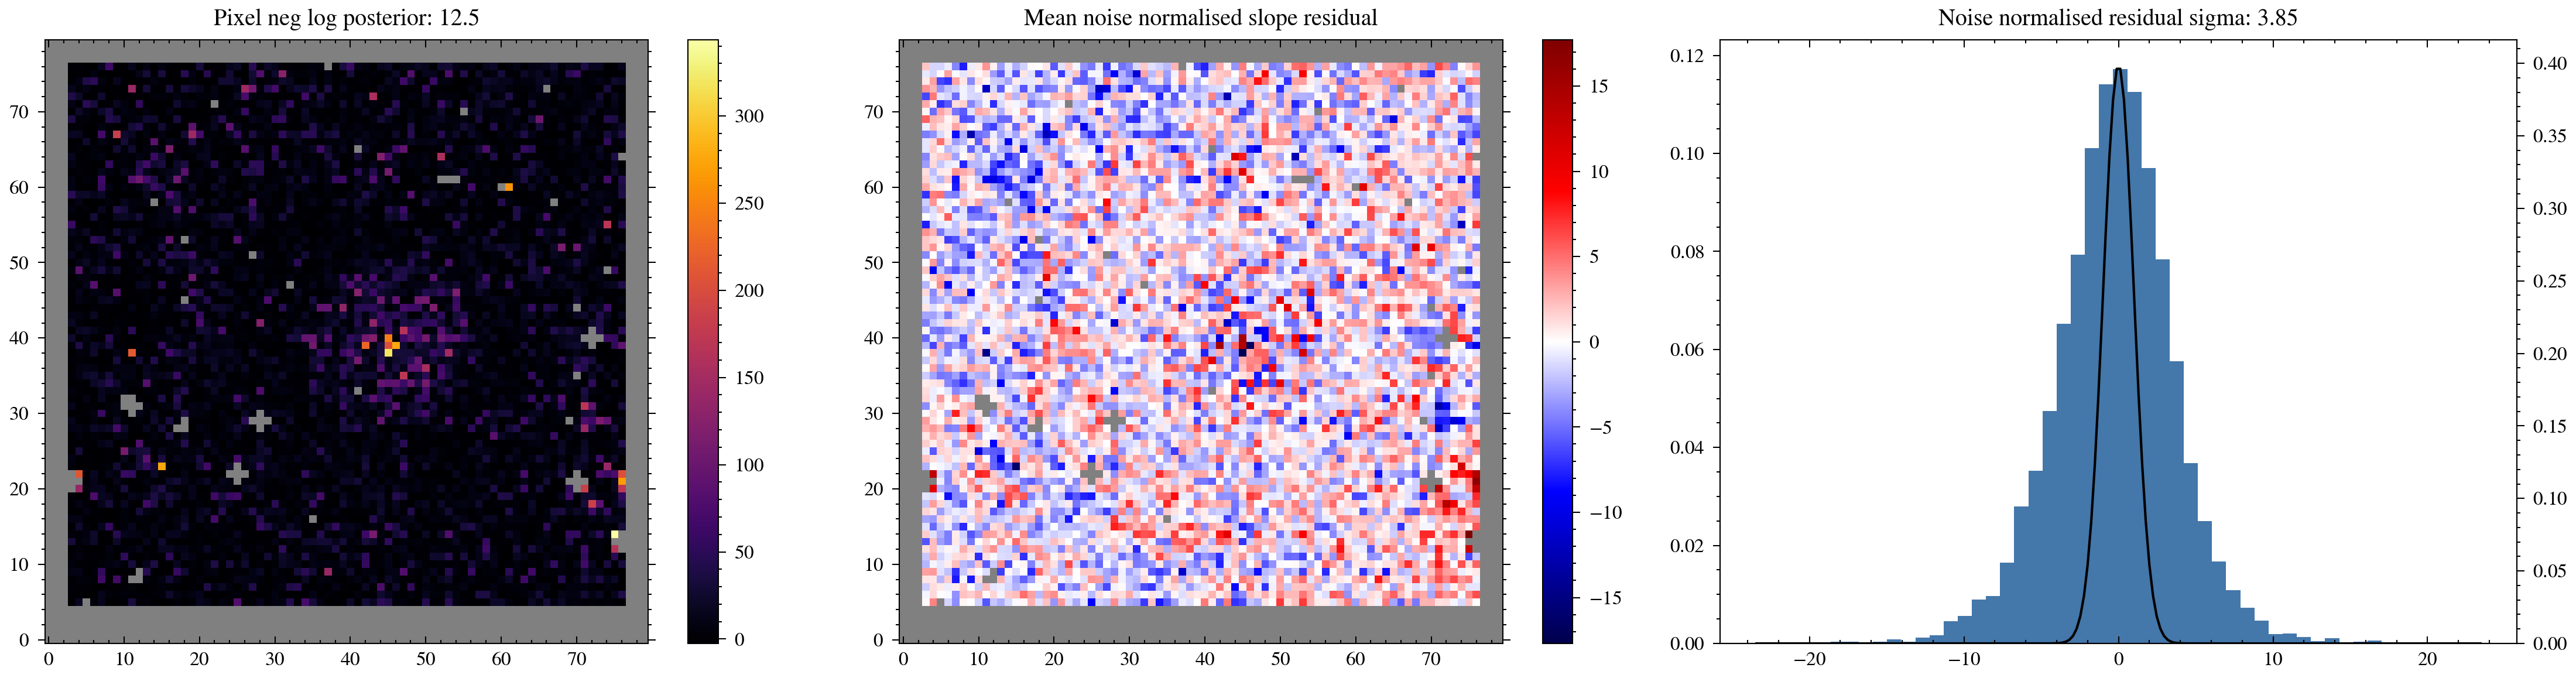

File 01843_002_01_06_1
Star HD-205827
Filter F430M
nints 1885
ngroups 7



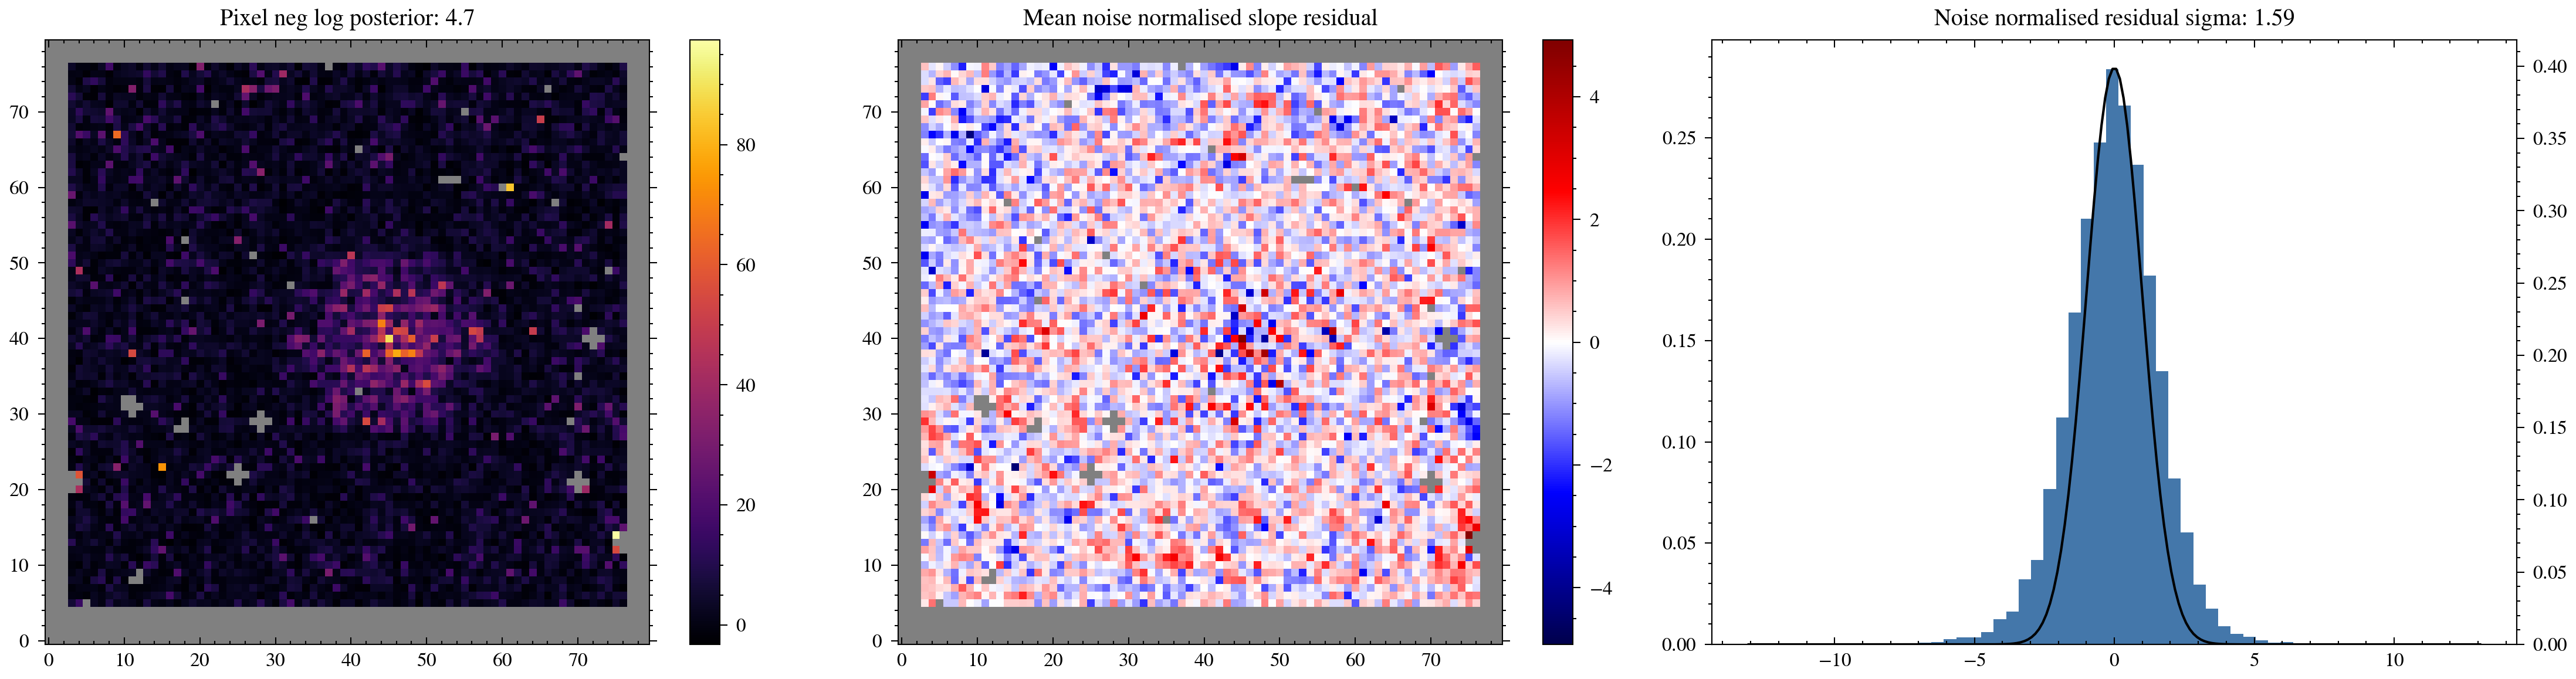

File 01843_001_01_05_1
Star HD-206893
Filter F480M
nints 720
ngroups 11



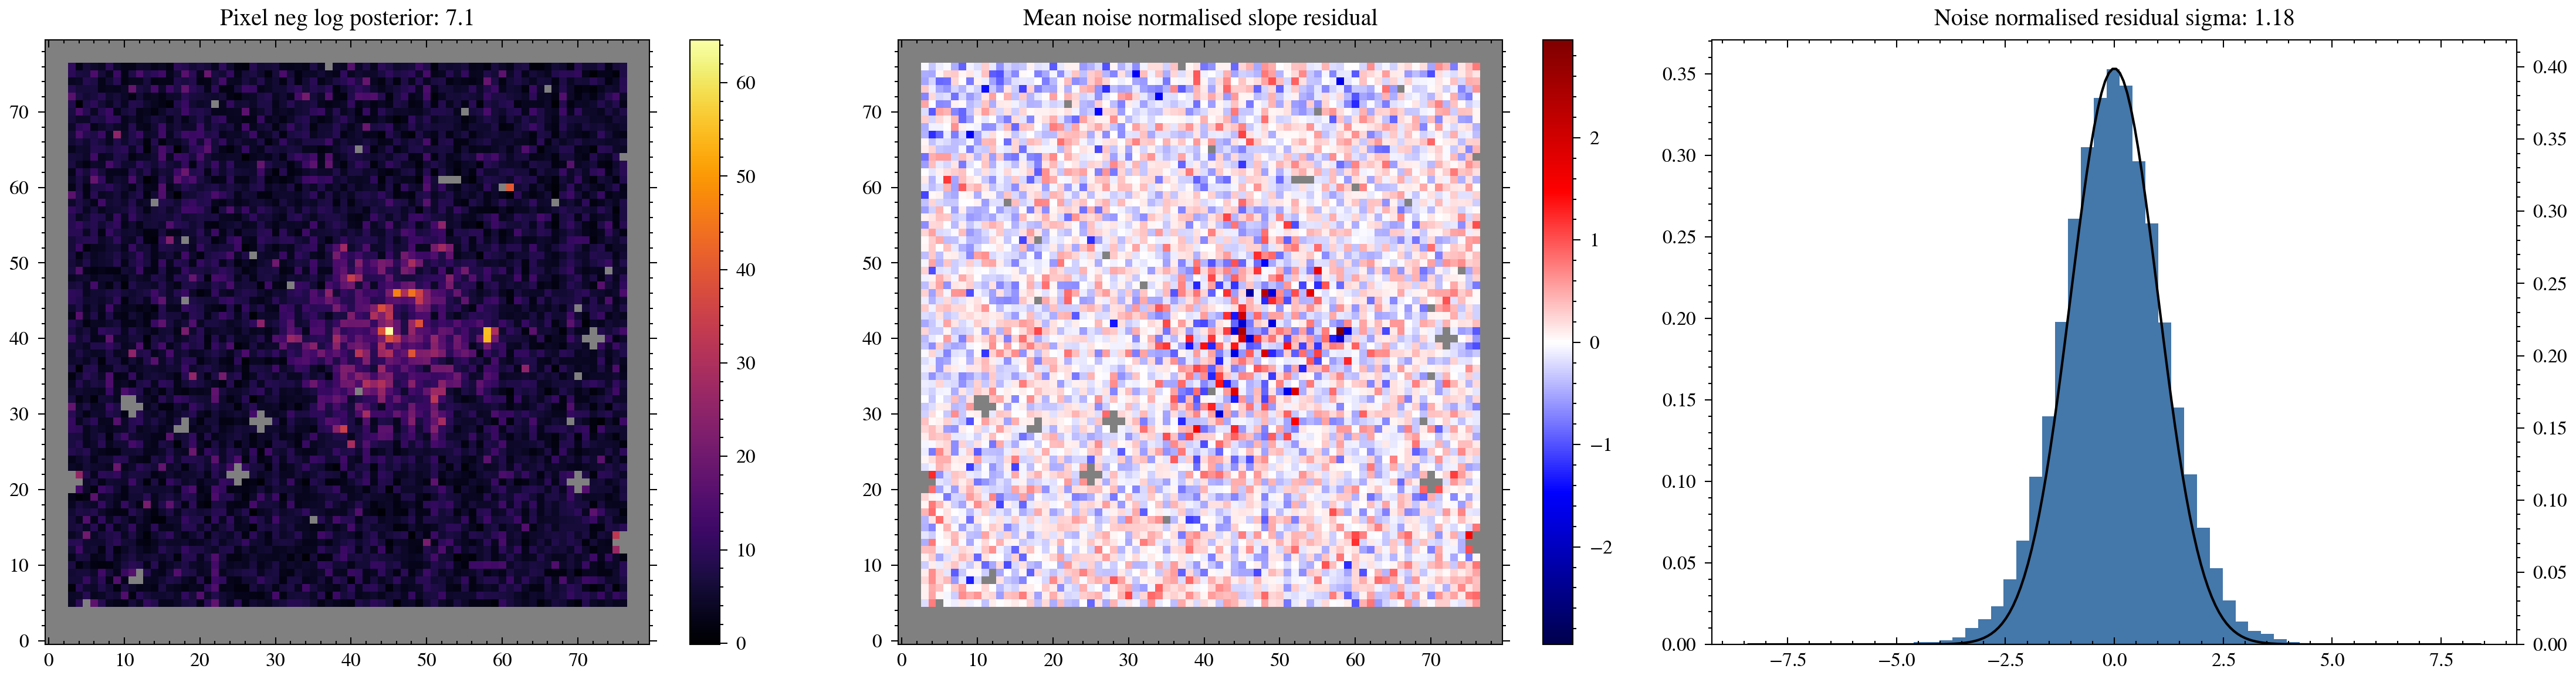

File 01843_001_01_06_1
Star HD-206893
Filter F380M
nints 7046
ngroups 4



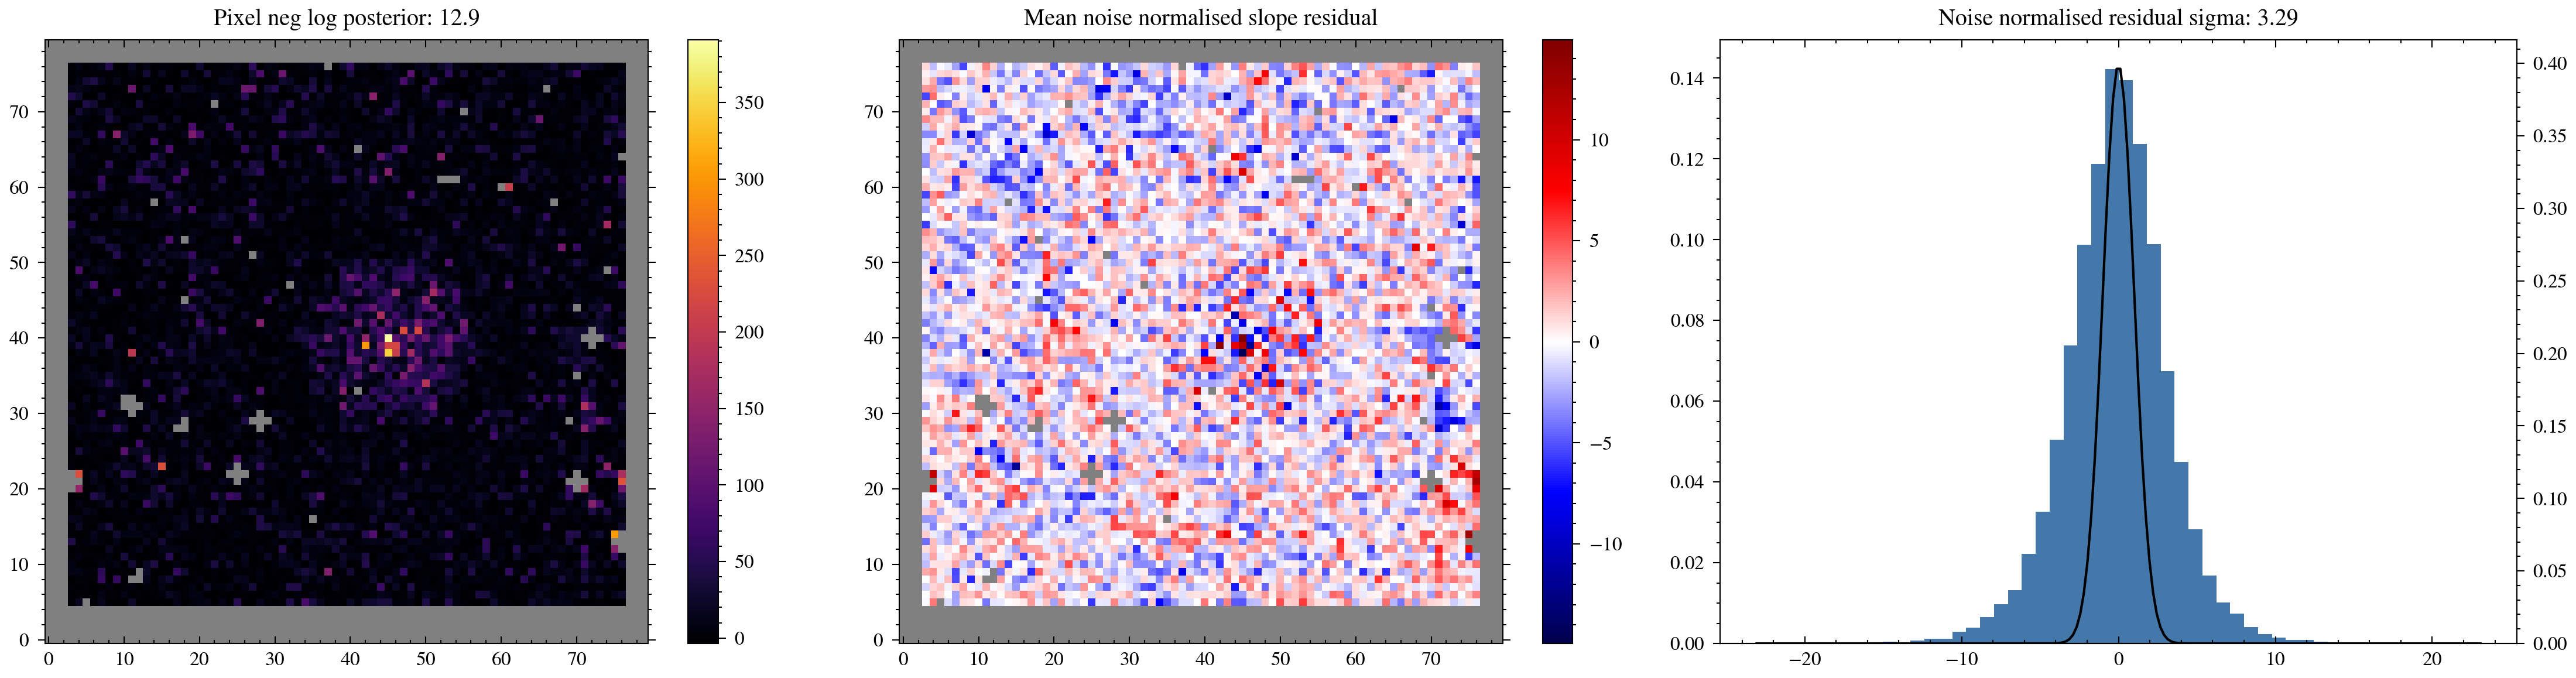

File 01843_001_01_07_1
Star HD-206893
Filter F430M
nints 2177
ngroups 8



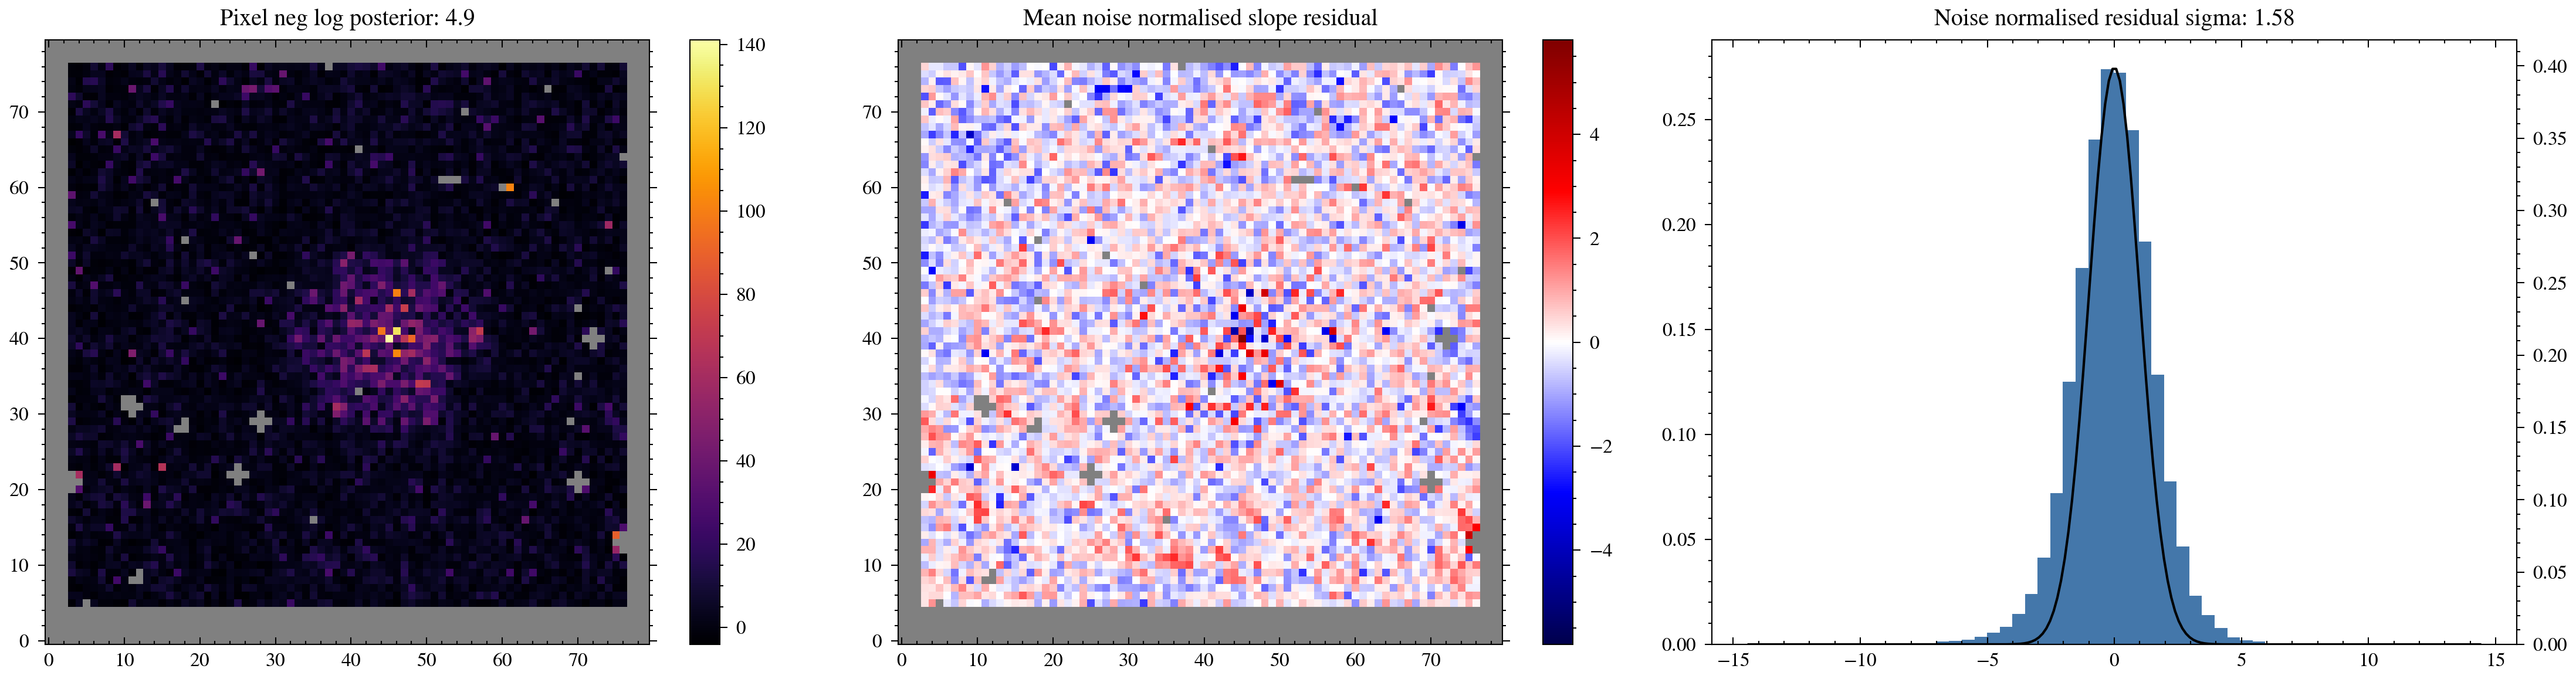

File 01843_002_01_04_1
Star HD-205827
Filter F480M
nints 641
ngroups 10



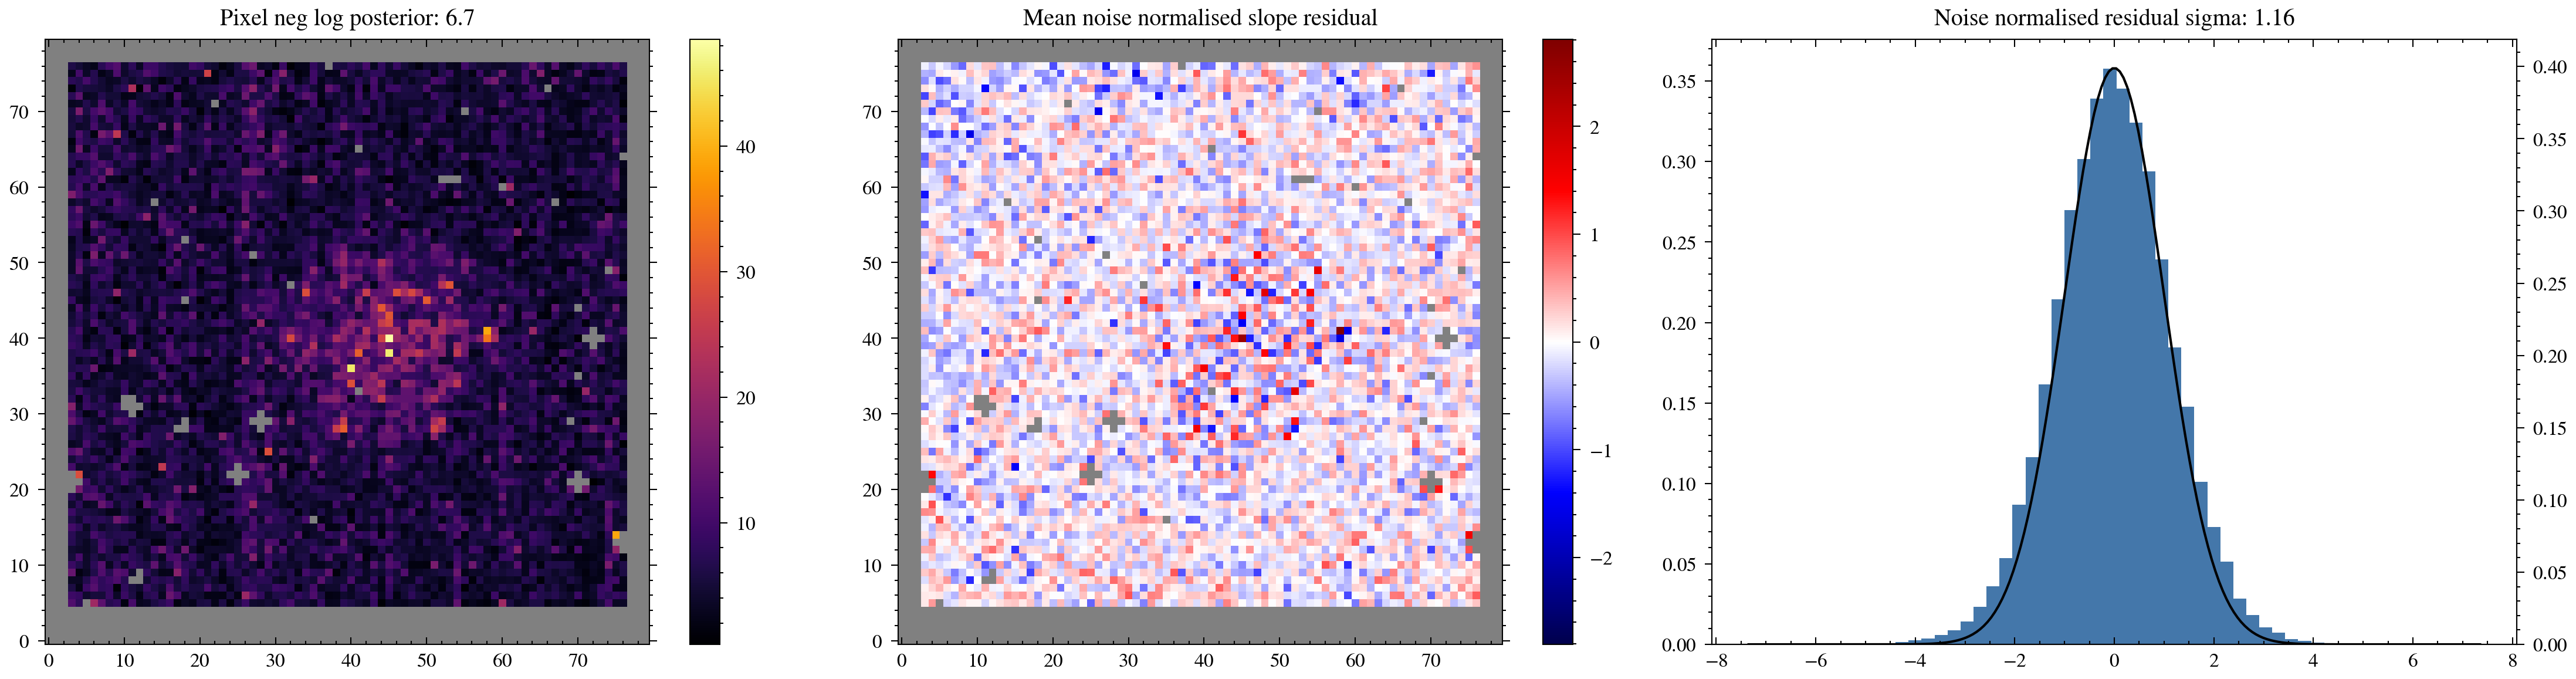

In [10]:
amigo.plotting.plot(result.history, save_path=save_path)
amigo.plotting.plot_losses(result.losses[0], 0)

for exp in exposures:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp, save_path=save_path)

In [11]:
# final_model = result.model
# final_state = {}
# for key, values in result.state.items():
#     final_state[key] = final_model.get(key)

In [ ]:
import equinox as eqx
import optimistix as optx
from amigo.stats import decompose
from amigo.core_models import ModelParams


@eqx.filter_jit
def fun(params, args):
    model, exp, model_params, proj_mats = args
    proj_fn = lambda x, P, x0: x0 + np.dot(P.T, x).reshape(x0.shape)
    model_params = jtu.map(proj_fn, params, proj_mats, model_params)
    return -np.nanmean(exp.mv_zscore(model_params.inject(model)))


params = [
    "amplitudes",
    "phases",
    "fluxes",
    # "aberrations",
    "spectra",
]
final_model = result.model

args_out, sols_out = {}, {}
for exp in exposures:
    opt_params, proj_mats = {}, {}
    for param in params:
        key = exp.map_param(param)
        opt_params[key] = final_model.get(key)
        fmat = -trainer.fishers[f"{exp.key}.{param}"]
        eig_vals, eig_vecs = decompose(fmat, normalise=False)
        proj_mats[key] = (eig_vals[None, :] ** -0.5) * eig_vecs

    opt_params = ModelParams(opt_params)
    proj_mats = ModelParams(proj_mats)

    #
    x0 = jtu.map(lambda x: np.zeros_like(x).flatten(), opt_params)
    args = (final_model, exp, opt_params, proj_mats)
    args_out[exp.key] = args

    print("Initial loss:", fun(x0, args))
    solver = optx.BFGS(rtol=1e-6, atol=1e-6)
    sol = optx.minimise(fun, solver, x0, args, throw=False, max_steps=2048)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

Initial loss: 14.870901953483195


In [ ]:
# spectra = {}
# for key, args in args_out.items():
#     model, exp, model_params, proj_mats = args
#     # TODO: Model this function into model params? Have it hold fishers?
#     proj_fn = lambda x, P, x0: x0 + np.dot(P.T, x).reshape(x0.shape)
#     model_params = jtu.map(proj_fn, sols_out[key].value, proj_mats, model_params)
#     final_model = model_params.inject(final_model)

#     # Spectra is joint-fit so we take the mean
#     exp = args[1]
#     spec = model_params.params[exp.map_param("spectra")]
#     spec_key = exp.get_key("spectra")
#     if spec_key not in spectra:
#         spectra[spec_key] = [spec]
#     else:
#         spectra[spec_key].append(spec)

# spectra = jtu.map(lambda x: np.array(x).mean(), spectra, is_leaf=lambda x: isinstance(x, list))
# final_model = final_model.set("spectra", spectra)

# final_state = {}
# for key, values in result.state.items():
#     final_state[key] = final_model.get(key)

In [ ]:
# for exp in exposures:
#     exp.print_summary()
#     amigo.plotting.summarise_fit(final_model, exp, save_path=this_save_path)

In [ ]:
from tqdm.auto import tqdm
from amigo.fisher import FIM


fmats = {}
for exp in tqdm(exposures):
    loglike_fn = lambda model: -np.nansum(exp.loglike(model))
    params = [exp.map_param("amplitudes"), exp.map_param("phases")]
    fmat = FIM(final_model, params, loglike_fn, reduce_ram=False, batch_size=30)
    fmats[exp.get_key("phases")] = fmat

In [ ]:
full_covs = jax.tree.map(lambda x: np.linalg.inv(x), fmats)

n = model.vis_model.n_basis
amp_covs = jax.tree.map(lambda x: x[:n, :n], full_covs)
phase_covs = jax.tree.map(lambda x: x[n:, n:], full_covs)

covs = {
    "amplitudes": amp_covs,
    "phases": phase_covs,
}

plt.figure(figsize=(12, 6))
for i, key in enumerate(amp_covs):
    if i > 5:
        break

    if i < 3:
        param = "amplitude"
        cov = amp_covs[key]
    else:
        param = "phase"
        cov = phase_covs[key]

    plt.subplot(2, 3, i + 1)
    plt.title(f"{param} Covariance")
    plt.imshow(cov, "coolwarm", norm=mpl.colors.CenteredNorm())
    # plt.imshow(np.log10(np.abs(cov)), inferno)
    plt.colorbar()
plt.show()